# Problem - Building with Ocean view

There are n buildings in a line. You are given an integer array heights of size n that represents the heights of the buildings in the line. The ocean is to the right of the buildings. A building has an ocean view if the building can see the ocean without obstructions. Formally, a building has an ocean view if all the buildings to its right have a smaller height. Return a list of indices (0-indexed) of buildings that have an ocean view, sorted in increasing order.

**Input**: `heights = [4,2,3,1]`

**Output**: `[0,2,3]`

Explanation: Building 2 (**1-indexed**) does not have an ocean view because building 3 is taller.


# ✅ Pattern: Reverse Scan + Running Maximum (Monotonic Insight)

This problem follows the **Right-to-Left Scan with a running maximum** pattern.

It’s similar to:
* Buildings with sunset view
* Stock span problems
* Finding leaders in an array
* “Next greater element to the right” logic
* Monotonic stack intuition (but optimized to O(1) space)

# 🎯 Intuition

The ocean is on the **right**, so:

A building at index i has an ocean view if:

> ***All buildings to its right have a smaller height.***

OR equivalently:

> ****The height at index i is strictly greater than every height to its right.***

This matches the classic **“leaders in array”** pattern.

Since we need to compare each building with the **maximum height to its right**, the natural strategy is:

**✔ Scan from right → left**

Because while scanning from right:
* Keep track of the **tallest building seen so far**.
* If `heights[i]` is **greater** than this maximum → it has an ocean view.
* Update the running maximum.

# 🔧 Technique (Step-by-Step)

**1️⃣ Start from the rightmost building**

The rightmost building always has ocean view (nothing to its right).

Initialize:

```
max_height = 0
result = []
```

**2️⃣ Loop from right → left**

For each building:

```
If heights[i] > max_height:
    building i has ocean view
    add i to result
Update max_height = max(max_height, heights[i])
```

**3️⃣ Reverse the result**

Because we collected indices in reverse order.

# 🧠 Dry Run

**Input**: `heights = [4, 2, 3, 1]`

**Start from right**:

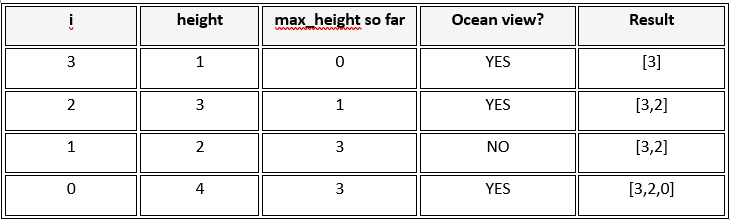

**Reverse result** → `[0, 2, 3]`

# Solution

In [4]:
def findBuildings(heights):
    result = []
    max_height = 0

    # Scan from right to left
    for i in range(len(heights)-1, -1, -1):
        if heights[i] > max_height:
            result.append(i)
            max_height = heights[i]

    return result[::-1]  # reverse to get increasing order

heights = [4,2,3,1]
print(findBuildings(heights))

[0, 2, 3]


**Time Complexity**: `O(n)`

**Space Complexity**: `O(n)`


# 🧩 Why This Works (Pattern Insight)

This is a **running maximum from the right**.

This avoids comparing each building with all buildings to the right.

**Time complexity: `O(n)`**

One pass from right → left.

**Space complexity: `O(1)` extra**

Just results + one variable.

**Avoids:**
* Sorting
* Stacks
* Nested loops

This is optimal.

# 🚀 Summary (One-Line Intuition)

* Scan from right, track the tallest building seen so far.
* A building has ocean view if it is taller than this running maximum.